# 08 · The random walk and the cumulative walk, on fake data

## Executive summary (read this first)

This notebook explains the team's two walk models (`forecast_models.py`) with **made-up data where we know
the truth**. Because we built the data ourselves, we can check that the model finds the right answer.

- **The fake data:** two interest rates, "2Y" and "10Y", 3 years of business days. Each day each rate moves
  by a random step. We choose the daily volatility (0.05 and 0.04 percentage points) and how much the two
  move together (correlation 0.8).
- **The random walk:** start at today's value. The spread after `h` days is `daily sd × √h`. Draw each
  horizon on its own.
- **The cumulative walk:** the same centre and spread, but each draw is **one path**: day 63 is reached by
  walking through day 21. So the two horizons of a draw are linked.

Each model is built **by hand**, step by step, and then checked against the production function: they give
the same numbers. At the end we score both against 2,000 simulated "true futures". They are equally good on
each horizon alone, but **the cumulative walk wins the joint score**, because real paths link the horizons.

Plain words used: **step** = one day's change. **sd** = standard deviation (the typical size of a step).
**draw** = one possible future the model writes down; a forecast is 1,000 draws.

## 0 — Setup

In [1]:
import importlib, pathlib, sys
import numpy as np, pandas as pd, pyarrow as pa
import matplotlib as mpl, matplotlib.pyplot as plt

HERE = pathlib.Path.cwd() if pathlib.Path.cwd().name == "f1_pipeline" else pathlib.Path.cwd() / "f1_pipeline"
REPO = HERE.parent
for p in (str(HERE), str(REPO)):
    if p not in sys.path: sys.path.insert(0, p)
import forecast_models as fm, backtest_m2 as bt
importlib.reload(fm)

pd.set_option("display.width", 200)
INK, INK2, GRID = "#0b0b0b", "#52514e", "#e6e5e1"
RW, CW = "#2a78d6", "#eb6834"                 # random walk, cumulative walk
ASSET = {"2Y": "#0b0b0b", "10Y": "#8a8983"}
mpl.rcParams.update({"figure.dpi": 110, "axes.spines.top": False, "axes.spines.right": False, "axes.grid": True,
                     "axes.axisbelow": True, "grid.color": GRID, "axes.edgecolor": INK2,
                     "axes.titlelocation": "left", "legend.frameon": False, "font.size": 10})

## 1 — Make the fake data

We decide the truth first:

| | 2Y | 10Y |
|---|---|---|
| start value | 3.00 % | 3.50 % |
| daily sd (true) | 0.05 | 0.04 |
| correlation of daily steps (true) | 0.8 | |

Then we generate 780 business days (about 3 years). Every day, both rates take one random step, drawn
together so they are correlated. No trend: on average a step is 0.

780 days, 2021-01-04 -> 2023-12-29.  Last values: 2Y 4.248, 10Y 3.923


,date,asset,value
0,2021-01-04,2Y,3.000000
1,2021-01-04,10Y,3.500000
2,2021-01-05,2Y,2.997570
3,2021-01-05,10Y,3.472462


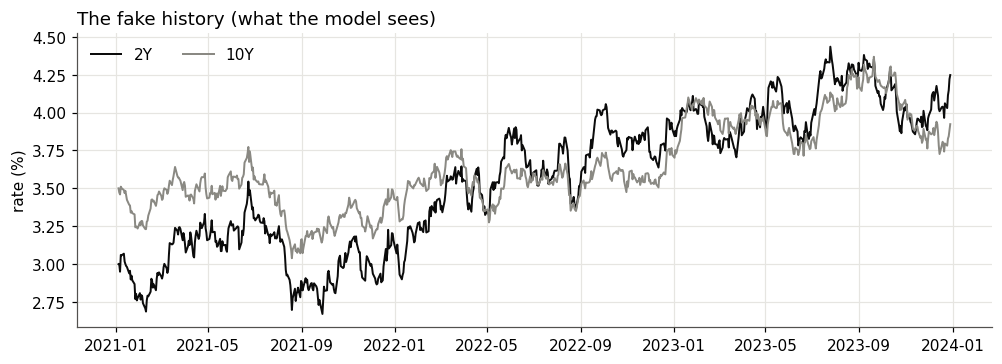

In [2]:
TRUE_SD = np.array([0.05, 0.04])
TRUE_CORR = 0.8
TRUE_COV = np.array([[1, TRUE_CORR], [TRUE_CORR, 1]]) * np.outer(TRUE_SD, TRUE_SD)
START = np.array([3.00, 3.50])
N_DAYS = 780

rng = np.random.default_rng(42)
dates = pd.bdate_range("2021-01-04", periods=N_DAYS)
steps_true = rng.multivariate_normal([0, 0], TRUE_COV, size=N_DAYS - 1)
levels = START + np.vstack([[0, 0], np.cumsum(steps_true, axis=0)])
wide = pd.DataFrame(levels, index=dates, columns=["2Y", "10Y"])

# the same long format as a real panel file: one row per (date, asset)
panel = pa.table({"date": [d.strftime("%Y-%m-%d") for d in dates for _ in range(2)],
                  "asset": ["2Y", "10Y"] * N_DAYS,
                  "value": wide.to_numpy().ravel().tolist()})
PANELS = {"fake_rates": panel}
ASOF = dates[-1].strftime("%Y-%m-%d")
print(f"{N_DAYS} days, {dates[0].date()} -> {ASOF}.  Last values: 2Y {wide['2Y'].iloc[-1]:.3f}, 10Y {wide['10Y'].iloc[-1]:.3f}")
display(panel.to_pandas().head(4))

fig, ax = plt.subplots(figsize=(9, 3.2), layout="constrained")
for a in wide: ax.plot(wide.index, wide[a], color=ASSET[a], lw=1.3, label=a)
ax.set_ylabel("rate (%)"); ax.legend(loc="upper left", ncols=2); ax.set_title("The fake history (what the model sees)")
plt.show()

In [3]:
wide

,2Y,10Y
2021-01-04,3.000000,3.500000
2021-01-05,2.997570,3.472462
2021-01-06,2.949938,3.459619
2021-01-07,3.060177,3.510955
2021-01-08,3.057730,3.501287
...,...,...
2023-12-25,4.029689,3.781818
2023-12-26,4.114407,3.828099
2023-12-27,4.147005,3.843763
2023-12-28,4.221300,3.884518


## 2 — Step 1: turn the history into daily steps, keep the last 260

The walk only cares about **how much the rate moves per day**, so it takes the day-to-day change. It keeps
the **last 260 steps** (about one year) and measures their sd. Production does the same in
`_step_frame()` and `_fit_walk()`.

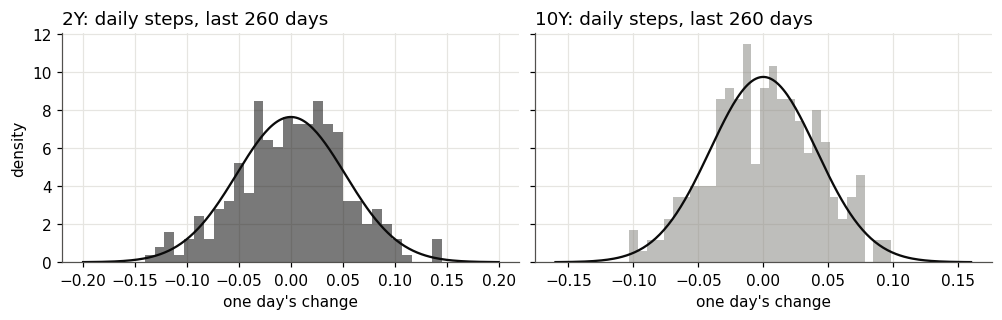

,true daily sd,measured (last 260 days)
2Y,0.05,0.0522
10Y,0.04,0.0409


In [4]:
steps = wide.diff().dropna().iloc[-260:]           # by hand
sd_hand = steps.std(ddof=0).to_numpy()              # numpy's std, as production uses

fig, axes = plt.subplots(1, 2, figsize=(9, 2.8), layout="constrained", sharey=True)
for ax, a, s_true, s_hat in zip(axes, wide.columns, TRUE_SD, sd_hand):
    ax.hist(steps[a], bins=30, density=True, color=ASSET[a], alpha=.55)
    x = np.linspace(-4 * s_true, 4 * s_true, 200)
    ax.plot(x, np.exp(-x**2 / (2 * s_hat**2)) / (s_hat * np.sqrt(2 * np.pi)), color=INK, lw=1.5)
    ax.set_title(f"{a}: daily steps, last 260 days"); ax.set_xlabel("one day's change")
axes[0].set_ylabel("density"); plt.show()

pd.DataFrame({"true daily sd": TRUE_SD, "measured (last 260 days)": sd_hand}, index=wide.columns).round(4)

The measured sd is close to the truth, but not exact: 260 days is a sample, so there is always some
estimation error. That is the only thing the walk learns about each rate's size of moves.

## 3 — Step 2: how the two rates move together (correlation and Cholesky)

The walk also measures the **correlation** of the two rates' steps. To draw correlated numbers, it uses a
small trick called the **Cholesky factor** `L` of the correlation matrix:

- draw two independent standard normals `z = (z1, z2)`;
- multiply: `z @ L.T`. The result has exactly the wanted correlation.

Below: 1,000 independent pairs (left) and the same pairs after multiplying by `L.T` (right).

measured correlation of daily steps: 0.793   (true: 0.8)
Cholesky factor L =
 [[1.    0.   ]
 [0.793 0.609]]


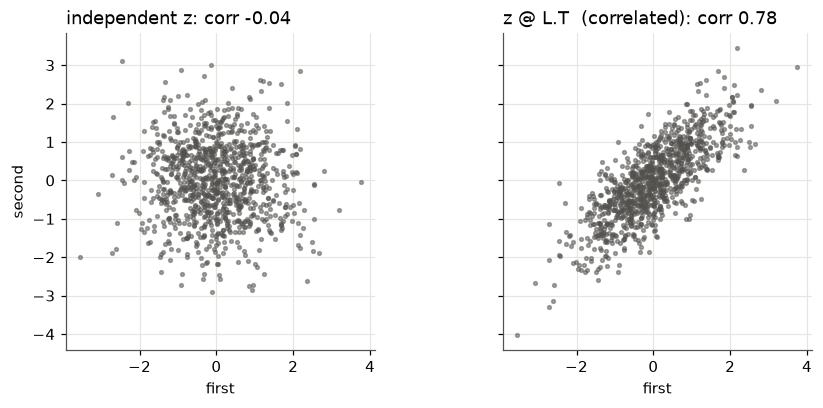

In [4]:
corr_hand = np.corrcoef(steps.to_numpy().T)
L = np.linalg.cholesky(corr_hand)
print(f"measured correlation of daily steps: {corr_hand[0, 1]:.3f}   (true: {TRUE_CORR})")
print("Cholesky factor L =\n", L.round(3))

z = np.random.default_rng(1).standard_normal((1000, 2))
zc = z @ L.T
fig, axes = plt.subplots(1, 2, figsize=(8, 3.6), layout="constrained", sharex=True, sharey=True)
for ax, data, title in ((axes[0], z, "independent z"), (axes[1], zc, "z @ L.T  (correlated)")):
    ax.scatter(data[:, 0], data[:, 1], s=6, color=INK2, alpha=.5)
    ax.set_title(f"{title}: corr {np.corrcoef(data.T)[0, 1]:.2f}"); ax.set_xlabel("first"); ax.set_aspect("equal")
axes[0].set_ylabel("second"); plt.show()

## 4 — The random walk, by hand

For each horizon `h` (here 21 and 63 business days), each draw is

```
value = last value + sd × √h × z        z = one correlated pair from §3
```

Each horizon gets its **own fresh** `z`. We build this by hand, then call the production function
`fm._random_walk_model` and compare. (Production also draws a second set of numbers per horizon for the
text model's `skew`; with skew = 0 they do not change the result, but they use up random numbers, so the
hand version draws them too, to stay in step.)

In [5]:
HORIZONS, N, SEED = [21, 63], 1000, 0
last = wide.iloc[-1].to_numpy()
NEUTRAL = {a: {"shift": 0.0, "widen": 1.0, "skew": 0.0} for a in wide.columns}

def random_walk_by_hand(seed=SEED):
    rng = np.random.default_rng(seed)
    out = np.empty((N, 2, len(HORIZONS)))
    for hi, h in enumerate(HORIZONS):
        zc = rng.standard_normal((N, 2)) @ L.T        # a fresh correlated pair for this horizon
        rng.standard_normal((N, 2))                   # production's skew draw (unused when skew = 0)
        out[:, :, hi] = last + zc * sd_hand * np.sqrt(h)
    return out

req = fm._Request(PANELS, ["2Y", "10Y"], HORIZONS, ASOF, NEUTRAL, N, SEED, "level", None)
rw_hand, rw_prod = random_walk_by_hand(), fm._random_walk_model(req)
print(f"by hand vs production fm._random_walk_model: max |difference| = {np.abs(rw_hand - rw_prod).max():.1e}")

q = lambda x: np.quantile(x, [0.05, 0.5, 0.95])
pd.DataFrame({f"{a} @ {h}d": q(rw_prod[:, ai, hi]) for ai, a in enumerate(wide.columns) for hi, h in enumerate(HORIZONS)},
             index=["5%", "median", "95%"]).round(3)

by hand vs production fm._random_walk_model: max |difference| = 8.9e-16


,2Y @ 21d,2Y @ 63d,10Y @ 21d,10Y @ 63d
5%,3.843,3.569,3.606,3.434
median,4.240,4.233,3.919,3.938
95%,4.646,4.973,4.211,4.429


**Why √h?** Each day adds an independent step. Independent variances add up, so after `h` days the
variance is `h × sd²` and the sd is `sd × √h`. The model does not simulate the days one by one; it jumps
straight to day `h`. Check: simulate 20,000 day-by-day paths and compare their day-63 spread with the
direct draw.

,"simulated day by day (20,000 paths)","direct draw, sd × √63"
5%,3.560,3.569
median,4.249,4.233
95%,4.928,4.973


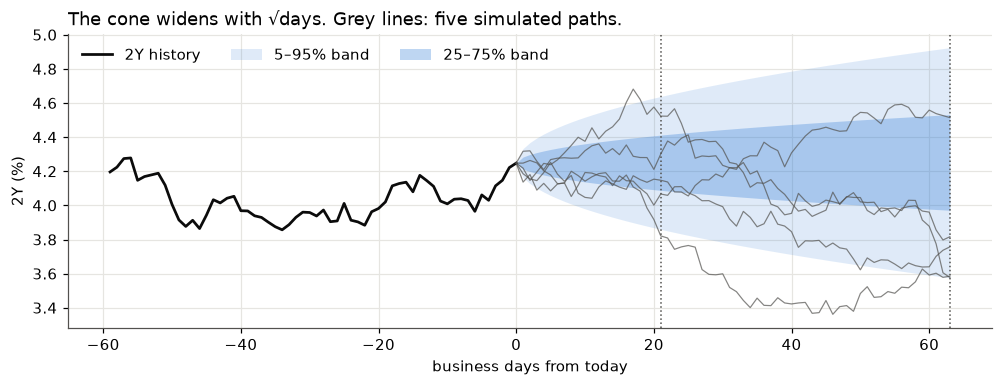

In [6]:
sim = np.random.default_rng(7).standard_normal((20000, 63)) * sd_hand[0]      # 2Y, one step per day
day63_by_days = last[0] + sim.sum(axis=1)
direct = rw_prod[:, 0, 1]
display(pd.DataFrame({"simulated day by day (20,000 paths)": q(day63_by_days), "direct draw, sd × √63": q(direct)},
                     index=["5%", "median", "95%"]).round(3))

fig, ax = plt.subplots(figsize=(9, 3.4), layout="constrained")
hist = wide["2Y"].iloc[-60:]
ax.plot(range(-59, 1), hist.to_numpy(), color=INK, lw=1.8, label="2Y history")
t = np.arange(0, 64)
for lo, hi_, alpha in ((0.05, 0.95, .15), (0.25, 0.75, .3)):
    zq = [np.quantile(np.random.default_rng(0).standard_normal(20000), p) for p in (lo, hi_)]
    ax.fill_between(t, last[0] + zq[0] * sd_hand[0] * np.sqrt(t), last[0] + zq[1] * sd_hand[0] * np.sqrt(t),
                    color=RW, alpha=alpha, lw=0, label=f"{int(lo*100)}–{int(hi_*100)}% band")
for p in sim[:5]:
    ax.plot(t, np.r_[last[0], last[0] + np.cumsum(p)], color=INK2, lw=0.8, alpha=.7)
for h in HORIZONS: ax.axvline(h, color=INK2, lw=1, ls=":")
ax.set_xlabel("business days from today"); ax.set_ylabel("2Y (%)"); ax.legend(loc="upper left", ncols=3)
ax.set_title("The cone widens with √days. Grey lines: five simulated paths."); plt.show()

## 5 — The cumulative walk, by hand

Same centre, same sd, same correlation. The only difference: **one path per draw**.

```
value at 21 = last value + sd × √21        × z1
value at 63 = value at 21 + sd × √(63 − 21) × z2        z1, z2 independent correlated pairs
```

Day 63 is reached by walking **through** day 21. Its spread is still `sd × √63` (21 + 42 = 63), so each
horizon on its own looks exactly like the random walk. What changes is the **link** between them.

In [7]:
def cumulative_walk_by_hand(seed=SEED):
    rng = np.random.default_rng(seed)
    out, path, prev = np.empty((N, 2, len(HORIZONS))), np.zeros((N, 2)), 0
    for hi, h in enumerate(HORIZONS):
        zc = rng.standard_normal((N, 2)) @ L.T
        rng.standard_normal((N, 2))                   # production's skew draw (unused when skew = 0)
        path = path + zc * sd_hand * np.sqrt(h - prev)   # add only the NEW days since the last horizon
        prev = h
        out[:, :, hi] = last + path
    return out

cw_hand, cw_prod = cumulative_walk_by_hand(), fm._cumulative_walk_model(req)
print(f"by hand vs production fm._cumulative_walk_model: max |difference| = {np.abs(cw_hand - cw_prod).max():.1e}")
pd.DataFrame({"random walk": [rw_prod[:, 0, 1].std(), np.corrcoef(rw_prod[:, 0, 0], rw_prod[:, 0, 1])[0, 1]],
              "cumulative walk": [cw_prod[:, 0, 1].std(), np.corrcoef(cw_prod[:, 0, 0], cw_prod[:, 0, 1])[0, 1]],
              "theory": [sd_hand[0] * np.sqrt(63), np.sqrt(21 / 63)]},
             index=["2Y sd at day 63", "corr(2Y @ 21, 2Y @ 63)"]).round(3)

by hand vs production fm._cumulative_walk_model: max |difference| = 8.9e-16


,random walk,cumulative walk,theory
2Y sd at day 63,0.414,0.414,0.414
"corr(2Y @ 21, 2Y @ 63)",-0.013,0.578,0.577


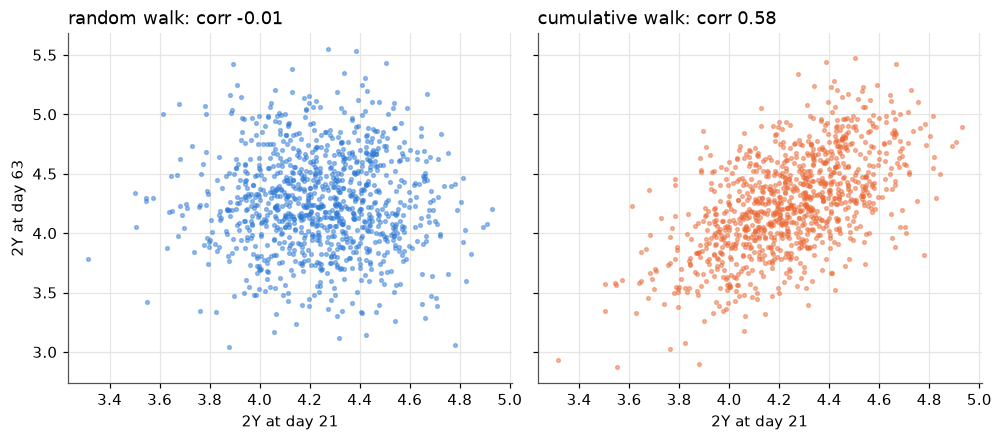

In [8]:
fig, axes = plt.subplots(1, 2, figsize=(9, 3.9), layout="constrained", sharex=True, sharey=True)
for ax, S, name, col in ((axes[0], rw_prod, "random walk", RW), (axes[1], cw_prod, "cumulative walk", CW)):
    ax.scatter(S[:, 0, 0], S[:, 0, 1], s=6, color=col, alpha=.45)
    ax.set_title(f"{name}: corr {np.corrcoef(S[:, 0, 0], S[:, 0, 1])[0, 1]:.2f}")
    ax.set_xlabel("2Y at day 21")
axes[0].set_ylabel("2Y at day 63"); plt.show()

- **Left (random walk):** knowing where 2Y is at day 21 tells you nothing about day 63. That is not how a real
  rate behaves: it cannot be high at day 21 and then, for no reason, be anywhere at day 63.
- **Right (cumulative walk):** a draw that is high at day 21 tends to stay high at day 63. The correlation is
  `√(21/63) = 0.58`, exactly what a real walk implies.

## 6 — Does the link matter for the score? Test against 2,000 true futures

Because we made the data, we can make the **real future** too: continue the true process from today, 2,000
times. For each true future we score both forecasts with the competition formula
(0.5 × CRPS + 0.3 × variogram + 0.2 × tail; lower is better).

,marginal,joint,tail,composite,cov90
random walk,0.1572,0.4885,0.0179,0.2287,0.9099
cumulative walk,0.1571,0.4495,0.0178,0.2169,0.9081


The cumulative walk has the better composite on 64% of the 2,000 true futures.


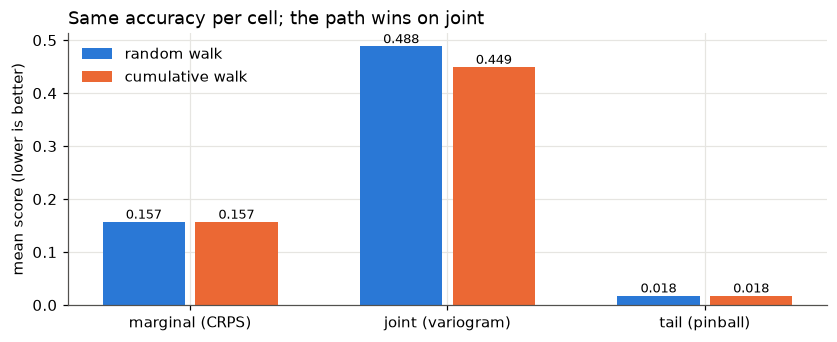

In [9]:
n_true = 2000
rng_f = np.random.default_rng(123)
future_steps = rng_f.multivariate_normal([0, 0], TRUE_COV, size=(n_true, 63))    # [future, day, asset]
future_paths = last + np.cumsum(future_steps, axis=1)
truth = np.stack([future_paths[:, h - 1, :] for h in HORIZONS], axis=2)          # [future, asset, horizon]

def cells(S):                      # [draw, asset, horizon] -> [draw, cell], asset-major like the scorer expects
    return S.reshape(S.shape[0], -1)

scores = {name: pd.DataFrame([bt.score_composite(cells(S), truth[i].reshape(-1)) for i in range(n_true)])
          for name, S in (("random walk", rw_prod), ("cumulative walk", cw_prod))}
parts = pd.DataFrame({k: v[["marginal", "joint", "tail", "composite", "cov90"]].mean() for k, v in scores.items()}).T
display(parts.round(4))
wins = (scores["cumulative walk"].composite < scores["random walk"].composite).mean()
print(f"The cumulative walk has the better composite on {wins:.0%} of the 2,000 true futures.")

fig, ax = plt.subplots(figsize=(7.5, 3), layout="constrained")
x = np.arange(3); wb = 0.36
for j, (name, col) in enumerate((("random walk", RW), ("cumulative walk", CW))):
    vals = parts.loc[name, ["marginal", "joint", "tail"]]
    ax.bar(x + (j - 0.5) * wb, vals, width=wb - 0.04, color=col, label=name)
    for xi, v in zip(x, vals): ax.text(xi + (j - 0.5) * wb, v, f"{v:.3f}", ha="center", va="bottom", fontsize=8.5)
ax.set_xticks(x, ["marginal (CRPS)", "joint (variogram)", "tail (pinball)"]); ax.set_ylabel("mean score (lower is better)")
ax.legend(loc="upper left"); ax.set_title("Same accuracy per cell; the path wins on joint"); plt.show()

- **Marginal and tail are the same:** each cell on its own has the same distribution in both models.
- **Joint (variogram) is better for the cumulative walk:** the variogram checks the *differences between
  cells*, such as 2Y at day 63 minus 2Y at day 21. The random walk gets that difference wrong because it
  treats the two horizons as unrelated.

This is exactly what we saw on the real F1 cards in notebook 07 §4.

## 7 — What the text model changes (`shift`, `widen`, `skew`)

The text model sends three numbers per asset. On the walk they do this:

- `shift`: moves every draw by the same amount (the centre moves);
- `widen`: multiplies the sd (the spread grows or shrinks around the centre);
- `skew`: tilts the shape, stretching one tail, while the mean and the variance stay the same.

,no adjustment,shift +0.10,widen 1.5,skew -0.6
mean,4.250,4.350,4.251,4.249
sd,0.416,0.416,0.623,0.416
1%,3.275,3.375,2.788,3.107
median,4.247,4.347,4.246,4.304
99%,5.222,5.322,5.709,5.009


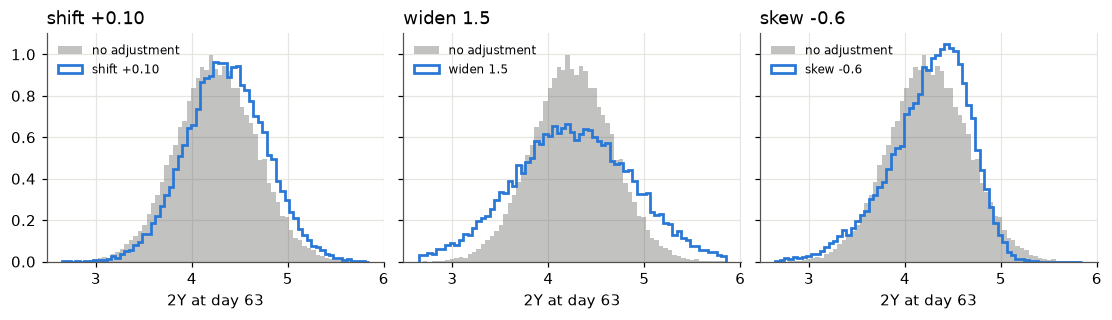

In [10]:
def walk_2y(shift=0.0, widen=1.0, skew=0.0):
    adj = dict(NEUTRAL); adj["2Y"] = {"shift": shift, "widen": widen, "skew": skew}
    r = fm._Request(PANELS, ["2Y", "10Y"], [63], ASOF, adj, 20000, 0, "level", None)
    return fm._random_walk_model(r)[:, 0, 0]

cases = {"no adjustment": walk_2y(), "shift +0.10": walk_2y(shift=0.10), "widen 1.5": walk_2y(widen=1.5),
         "skew -0.6": walk_2y(skew=-0.6)}
display(pd.DataFrame({k: [v.mean(), v.std(), *np.quantile(v, [0.01, 0.5, 0.99])] for k, v in cases.items()},
                     index=["mean", "sd", "1%", "median", "99%"]).round(3))

fig, axes = plt.subplots(1, 3, figsize=(10, 2.8), layout="constrained", sharey=True)
bins = np.linspace(last[0] - 1.6, last[0] + 1.6, 70)
for ax, k in zip(axes, ["shift +0.10", "widen 1.5", "skew -0.6"]):
    ax.hist(cases["no adjustment"], bins=bins, density=True, color=INK2, alpha=.35, label="no adjustment")
    ax.hist(cases[k], bins=bins, density=True, histtype="step", lw=1.8, color=RW, label=k)
    ax.set_title(k); ax.set_xlabel("2Y at day 63"); ax.legend(loc="upper left", fontsize=8)
plt.show()

## 8 — Summary

| | random walk | cumulative walk |
|---|---|---|
| centre | last value (+ text `shift`) | same |
| spread at `h` days | sd of last 260 steps × √h (× text `widen`) | same |
| assets move together | yes, via the Cholesky factor | same |
| horizons linked | **no**, each horizon is a fresh draw | **yes**, one path per draw: corr √(h₁/h₂) |
| per-cell accuracy (marginal, tail) | same | same |
| joint score | worse on multi-horizon cards | **better** |
| used in production for | single-horizon cards (F2, F4) | multi-horizon cards (F3, and F1 when M2 is not used) |

On a card with one horizon the two models are identical. The only reason to prefer the cumulative walk is
multi-horizon cards, where real values are linked through time.

**What neither walk does:** no trend and no mean reversion; one volatility number from the last year; a
normal bell-curve shape (unless the text adds `skew`). Those are the gaps a model like M2 tries to fill.